In [ ]:
# Import required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from scipy.stats import boxcox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
from scipy.special import inv_boxcox
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, InputLayer
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

In [324]:
# Set plot parameter
plt.rcParams['figure.figsize'] = (10, 7.5)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [325]:
# Read data file
oil_df = pd.read_csv('.\oil_prices_2426.csv', parse_dates=['date'], index_col='date', dayfirst=True)

# Rename column 
oil_df.rename(columns={'price (dollars)': 'price'}, inplace=True)

# Set the frequency to daily
oil_df.index.freq = 'D'


# Preview data
oil_df.head()

,price
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21


In [326]:
# Display data info
oil_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 500 entries, 2024-09-21 to 2026-02-02
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   500 non-null    float64
dtypes: float64(1)
memory usage: 7.8 KB


In [327]:
# Summary statistics
oil_df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
price,500.0,75.87,42.91,16.48,35.37,64.29,111.57,158.78


In [ ]:
print(f"Missing Values: {oil_df.isnull().sum()}")
print('/n')
print(f'Oil price date ranges from {oil_df.index.min()} to {oil_df.index.max()}')


Missing Values: price    0
dtype: int64
/n
Oil price date ranges from 2024-09-21 00:00:00 to 2026-02-02 00:00:00


<Figure size 1800x600 with 0 Axes>

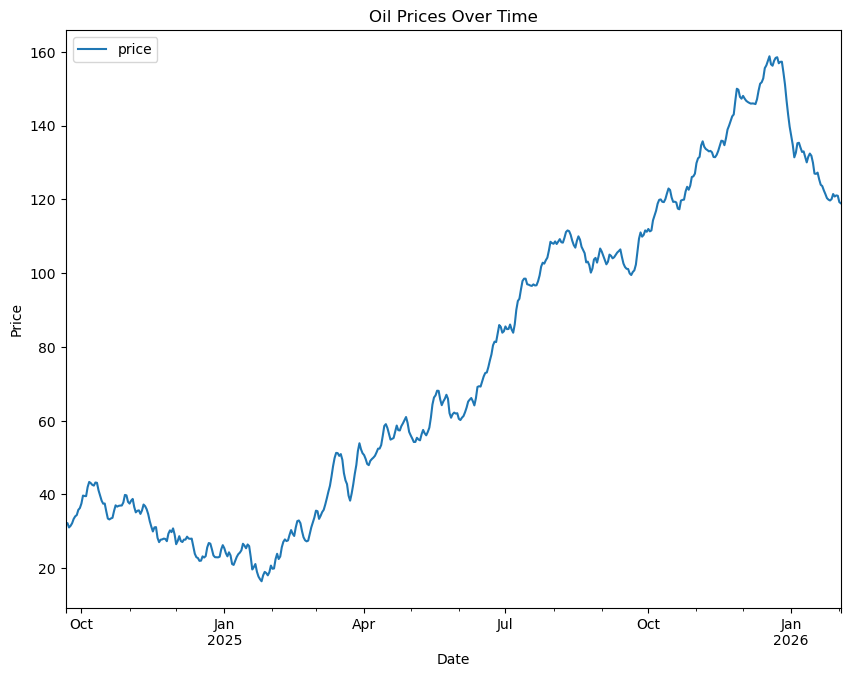

In [ ]:
# Plot time series plot
fig, ax = plt.subplots(figsize=(14,6))
oil_df['price'].plot()
plt.title('Oil Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

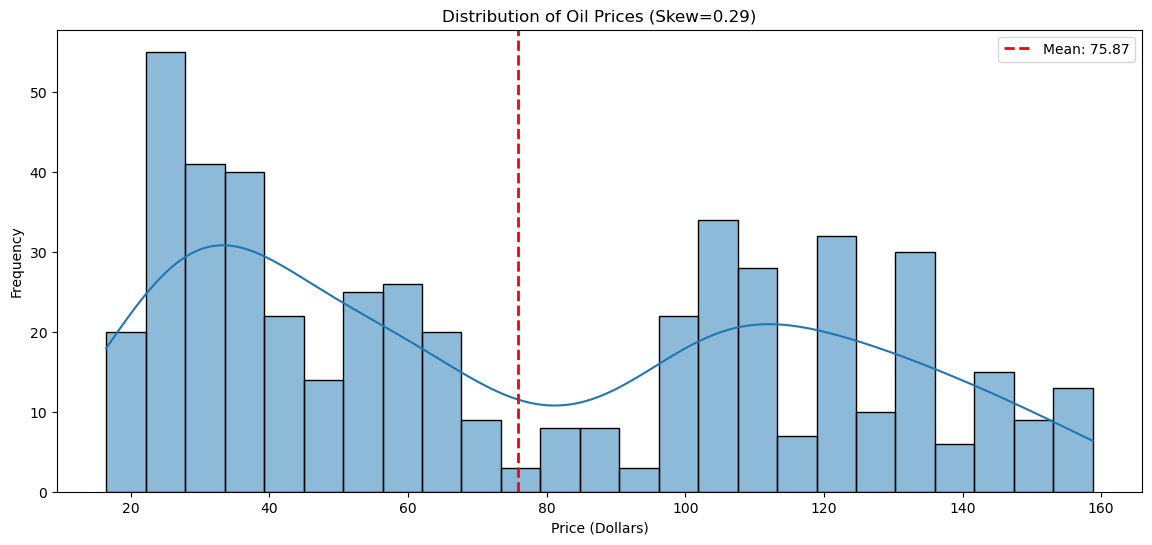

In [330]:
plt.figure(figsize=(14,6))
sns.histplot(oil_df['price'], bins=25, kde=True)
plt.axvline(oil_df['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {oil_df['price'].mean():.2f}')
plt.title(f'Distribution of Oil Prices (Skew={oil_df['price'].skew():.2f})')
plt.xlabel('Price (Dollars)')
plt.ylabel('Frequency')
plt.legend(loc='best')
plt.show()

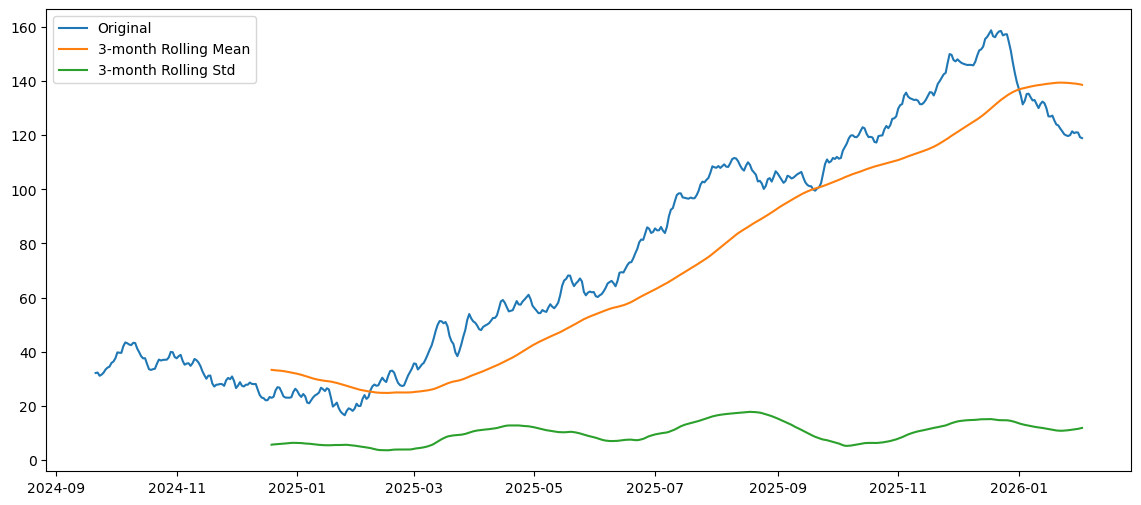

In [331]:
rolling_mean = oil_df['price'].rolling(window=90).mean()
rolling_std = oil_df['price'].rolling(window=90).std()

plt.figure(figsize=(14,6))

plt.plot(oil_df['price'], label='Original')
plt.plot(rolling_mean, label='3-month Rolling Mean')
plt.plot(rolling_std, label='3-month Rolling Std')

plt.legend()
plt.show()

In [332]:
# Extract year and month from the date index
oil_df['month_name'] = oil_df.index.strftime('%B')
oil_df['year'] = oil_df.index.strftime('%Y')

In [333]:
# Order the months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# Find the mean oil price for each month across all years
monthly_avg = oil_df.groupby('month_name')['price'].mean().round(2).reindex(month_order)

# Print the monthly average oil prices
monthly_avg

month_name
January       74.76
February      33.99
March         43.90
April         54.82
May           60.83
June          71.76
July          95.94
August       106.92
September     86.92
October       79.12
November      84.81
December      88.36
Name: price, dtype: float64

In [334]:
# Find the mean oil price for each year
yearly_avg = oil_df.groupby('year')['price'].mean().round(2)

# Print the yearly average oil prices
yearly_avg

year
2024     32.23
2025     83.44
2026    127.09
Name: price, dtype: float64

In [335]:
# Find the mean oil price for each month in each year
monthly_yearly_avg = oil_df.pivot_table(values='price', index='month_name', columns='year', aggfunc='mean', fill_value=0).round(2).reindex(month_order)

# Print the monthly average oil prices for each year
monthly_yearly_avg

year,2024,2025,2026
month_name,,,
January,0.00,21.92,127.61
February,0.00,27.92,119.08
March,0.00,43.90,0.00
April,0.00,54.82,0.00
May,0.00,60.83,0.00
June,0.00,71.76,0.00
July,0.00,95.94,0.00
August,0.00,106.92,0.00
September,33.32,104.79,0.00


In [ ]:
# Function for getting the metrics of each model
def evaluate_model(actual, predicted, model_name="Model"):
    
    actual = np.array(actual).flatten()
    predicted = np.array(predicted).flatten()
    
    mae = np.round(mean_absolute_error(actual, predicted), 2)
    rmse = np.round(np.sqrt(mean_squared_error(actual, predicted)), 2)
    mape = np.round(mean_absolute_percentage_error(actual, predicted) * 100, 2)

    print(f"{model_name} Performance:")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"R2   : {r2:.2f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [337]:
# Split data into training and test
train_size = int(len(oil_df) * 0.8)

train = oil_df.iloc[:train_size]
test = oil_df.iloc[train_size:]

In [338]:
# Transform the data using Box-Cox transformation to stabilize variance
train['price_transformed'], lambda_ = boxcox(train['price'])

# Print lambda
print('Lambda: %f' % lambda_)

Lambda: 0.030242


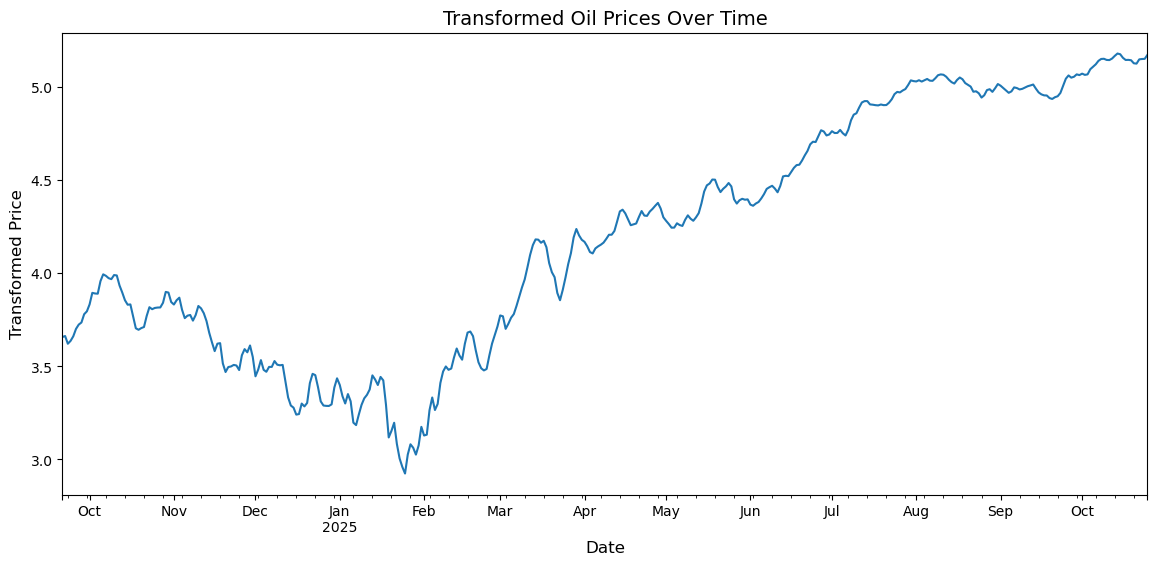

In [339]:
# Plot the transformed data
fig, ax = plt.subplots(figsize=(14, 6))
train['price_transformed'].plot()
plt.title('Transformed Oil Prices Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Transformed Price', fontsize=12)
plt.show()

In [340]:
# Function to Plot ACF and PACF plots
def plot_acf_pacf(series, lag_value, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)
    plot_acf(series, ax=axes[0], lags=lag_value)
    plot_pacf(series, ax=axes[1], lags=lag_value)
    
    # Set titles and labels for ACF plots
    axes[0].set_title(f'{title} - Autocorrelation (ACF)', fontsize=14)
    axes[0].set_xlabel('Lag, k', fontsize=12)
    axes[0].set_ylabel('Correlation Coefficient', fontsize=12)
    axes[0].grid(True, which='major', linestyle='--', alpha=0.2)
    
    # Set titles and labels for PACF plots
    axes[1].set_title(f'{title} - Partial Autocorrelation (PACF)', fontsize=14)
    axes[1].set_xlabel('Lag, k', fontsize=12)
    axes[1].set_ylabel('Correlation Coefficient', fontsize=12)
    axes[1].grid(True, which='major', linestyle='--', alpha=0.2)
    
    plt.tight_layout()
    plt.show()

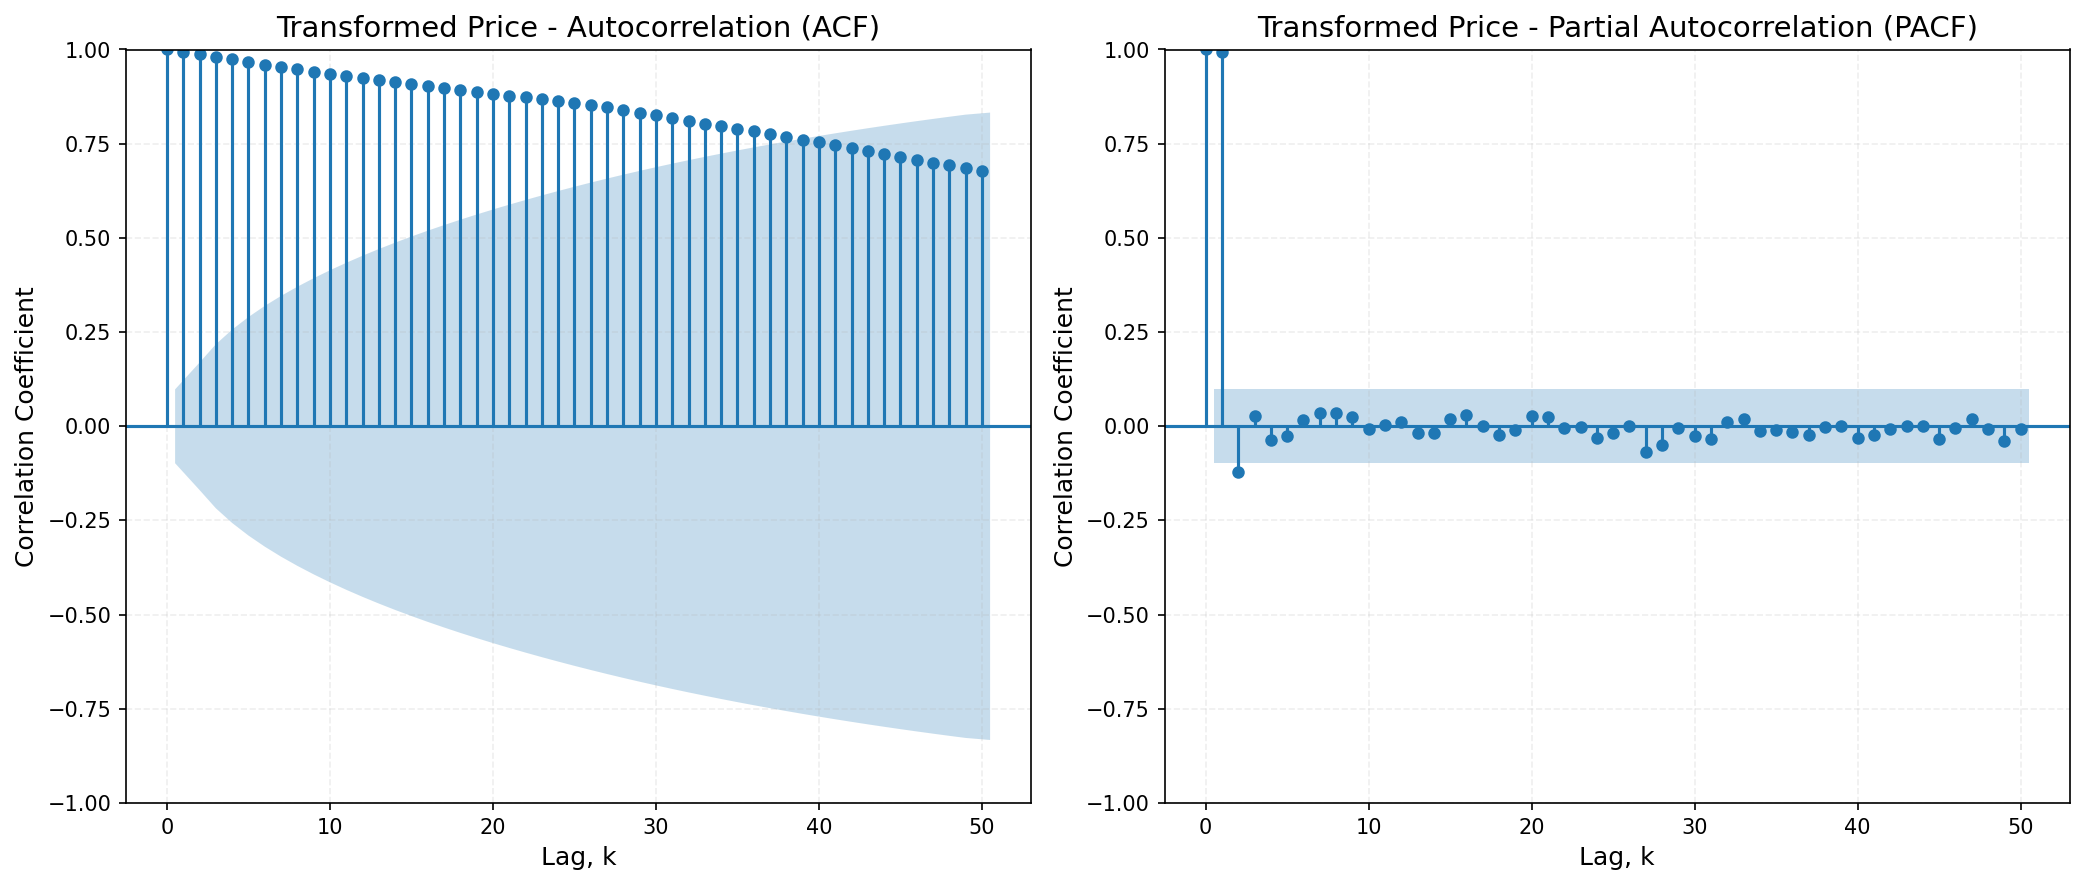

In [341]:
# Plot the ACF and PACF so we can assess the correlations in the data (lags) and see if it looks stationary
plot_acf_pacf(train['price_transformed'], 50, 'Transformed Price')

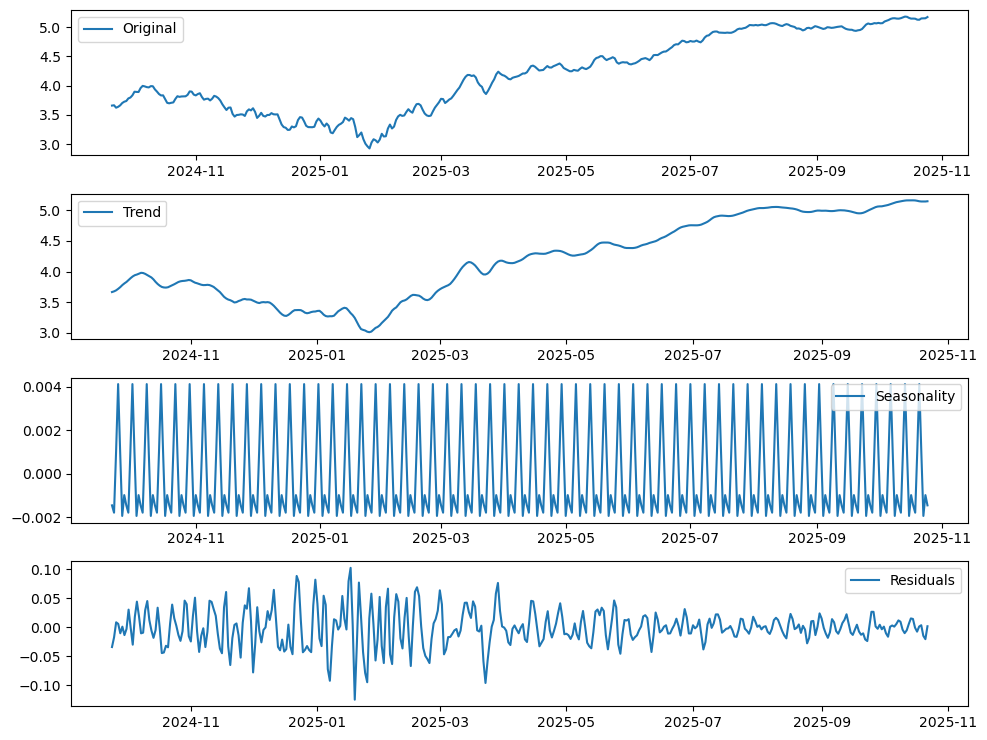

In [342]:
# build seasonal decomposition model
decomposition = seasonal_decompose(train['price_transformed'], model='additive')

# Plot the decomposition results
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid


plt.subplot(411)
plt.plot(train['price_transformed'], label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [343]:
''' Use the Augmented Dickey-Fuller test and KPSS test to check for stationarity '''"ADST Tutorials"


# ADF Test function
def stationarity_test(series):
    
    # ADF Test
    adf_result = adfuller(series.dropna())
    print('Augmented Dickey-Fuller Test Results:')
    print(f'ADF Statistic: {adf_result[0]:.2f}')
    print(f'p-value: {adf_result[1]:.2f}')
    print('Critical Values:')
    for key, value in adf_result[4].items():
        print(f'\t{key}: {value:.2f}')  
        
    if adf_result[1] < 0.05:
        print(f"Time series is stationary (reject null hypothesis)")
    else:
        print(f"Time series is non-stationary (fail to reject null hypothesis)")

    print('=='*30)

    # KPSS Test function
    kpss_result = kpss(series.dropna(), regression='c')
    print('KPSS Test Results:')
    print(f'KPSS Statistic: {kpss_result[0]:.2f}')
    print(f'p-value: {kpss_result[1]:.2f}')
    
    if kpss_result[1] > 0.05:
        print(f"Time series is stationary (reject null hypothesis)")
    else:
        print(f"Time series is non-stationary (fail to reject null hypothesis)")

In [344]:
# Perform the ADF and KPSS tests to check for stationarity
stationarity_test(train['price_transformed'])

Augmented Dickey-Fuller Test Results:
ADF Statistic: 0.20
p-value: 0.97
Critical Values:
	1%: -3.45
	5%: -2.87
	10%: -2.57
Time series is non-stationary (fail to reject null hypothesis)
KPSS Test Results:
KPSS Statistic: 2.76
p-value: 0.01
Time series is non-stationary (fail to reject null hypothesis)


In [345]:
# Difference the data to make it stationary
train['price_diff'] = train['price_transformed'].diff()

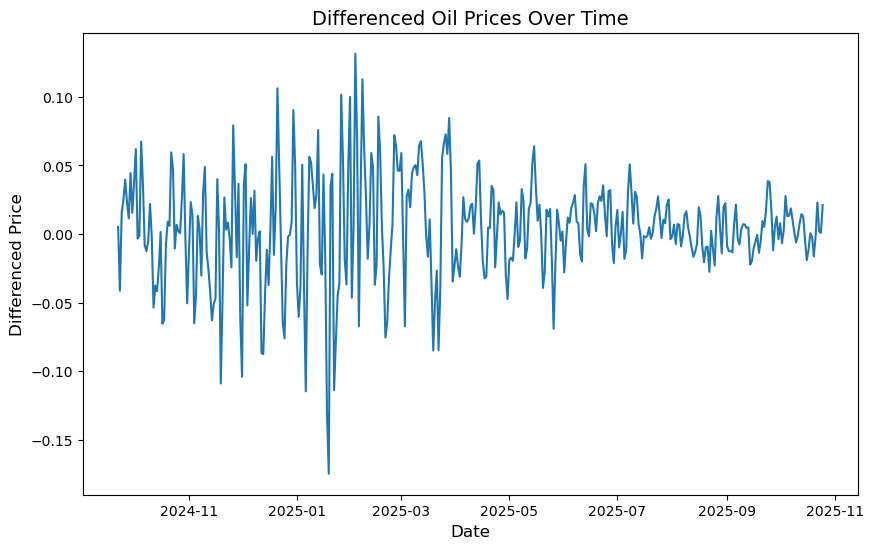

In [346]:
# Plot the differenced data
plt.figure(figsize=(10, 6))
plt.plot(train['price_diff'], label='Differenced Data')
plt.title('Differenced Oil Prices Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Differenced Price', fontsize=12)
plt.show()

In [347]:
# Perform the ADF and KPSS tests on the differenced series
stationarity_test(train['price_diff'])

Augmented Dickey-Fuller Test Results:
ADF Statistic: -5.74
p-value: 0.00
Critical Values:
	1%: -3.45
	5%: -2.87
	10%: -2.57
Time series is stationary (reject null hypothesis)
KPSS Test Results:
KPSS Statistic: 0.16
p-value: 0.10
Time series is stationary (reject null hypothesis)


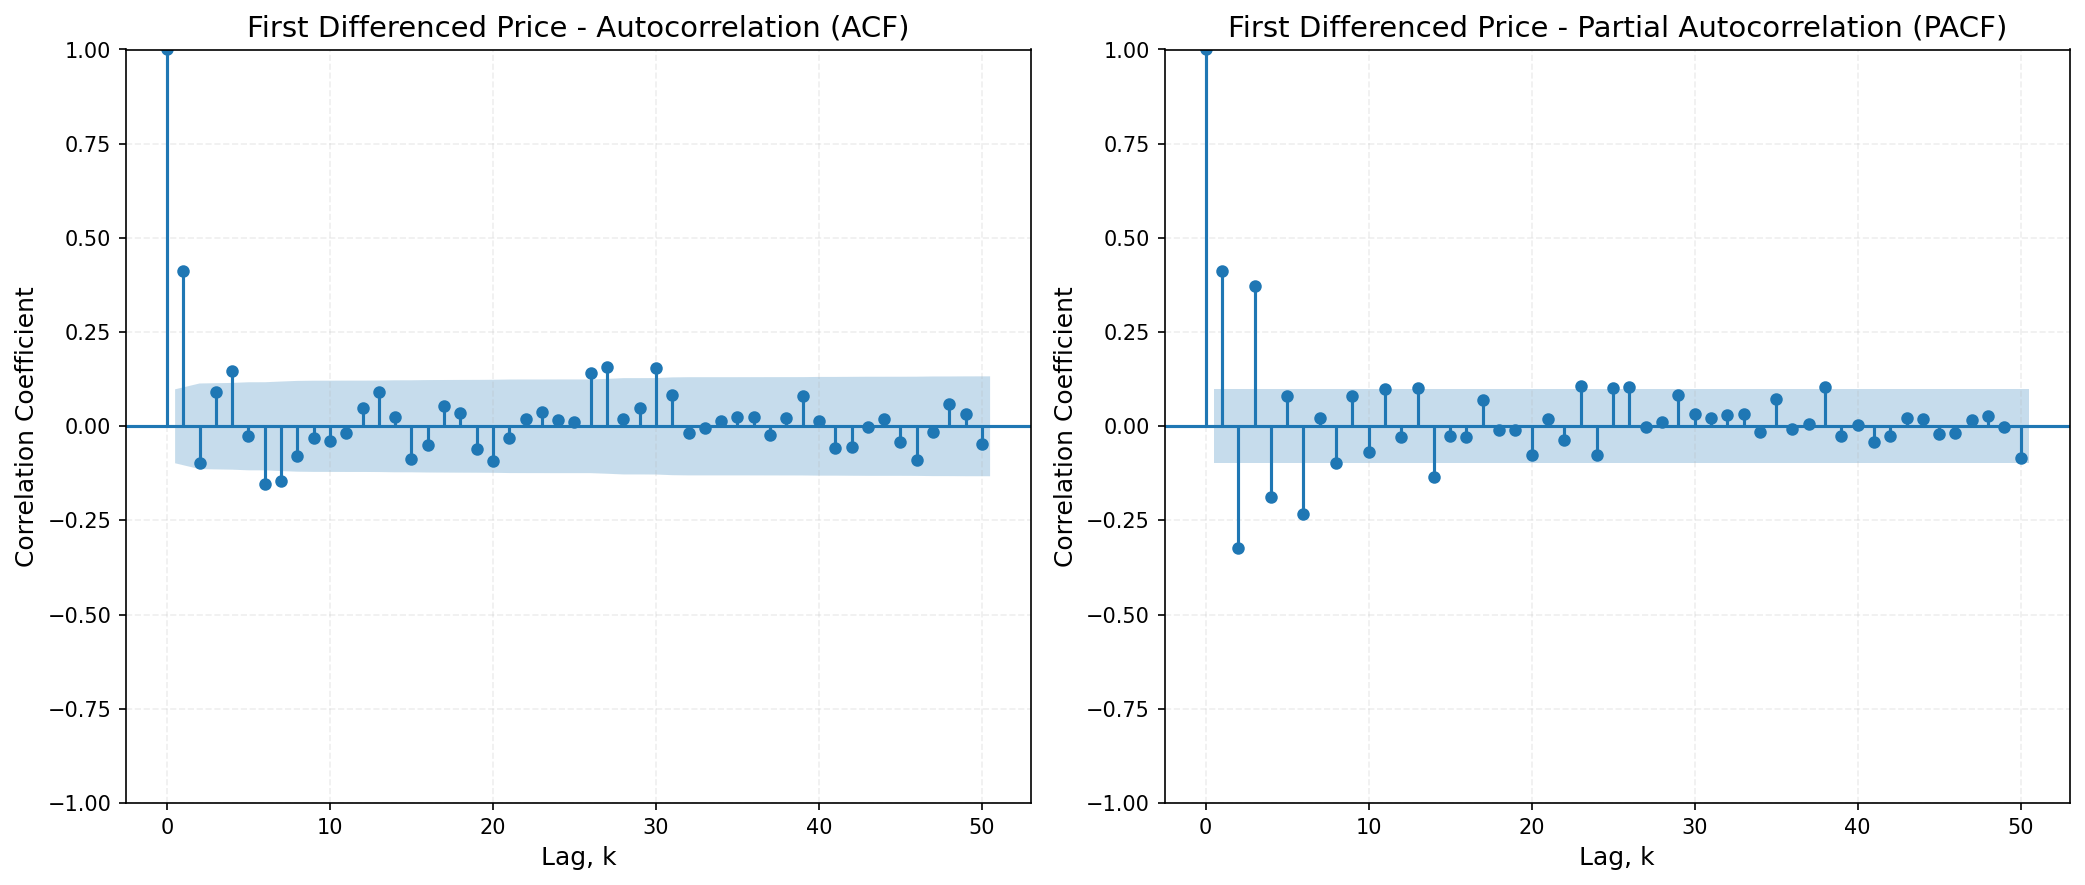

In [348]:
# Plot the ACF and PACF of the differenced series to determine the order of the ARIMA model
plot_acf_pacf(train['price_diff'].dropna(), 50, 'First Differenced Price')

# BUILDING ARIMA MODEL
This section focuses on working with arma/arima model for time series forecasting

In [349]:
# Define the ARIMA model with the identified order (p, d, q)
model = ARIMA(train['price_transformed'], order=(4, 1, 12))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      price_transformed   No. Observations:                  400
Model:                ARIMA(4, 1, 12)   Log Likelihood                 868.695
Date:                Sun, 08 Mar 2026   AIC                          -1703.390
Time:                        21:47:25   BIC                          -1635.577
Sample:                    09-21-2024   HQIC                         -1676.532
                         - 10-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2621      1.508      0.174      0.862      -2.694       3.218
ar.L2         -0.5720      0.514     -1.112      0.266      -1.580       0.436
ar.L3         -0.0426      0.798     -0.053      0.9

In [350]:
# Find the best ARIMA model using AIC and BIC criteria
def find_best_arima_model(series, max_p, max_d, max_q):
    best_aic, best_order_aic = float('inf'), None
    model_order, aic_value = [], []
    num_of_combinations = 0 # Counter for number of combinations evaluated
    
    # Loop through all combinations of p, d, q and fit the ARIMA model
    for d in range(0,max_d+1):
        for p in range(0,max_p+1):
            for q in range(0,max_q+1):
                try:
                    model = ARIMA(series, order=(p, d, q))
                    model_fit = model.fit()
                    aic = model_fit.aic
                    model_order.append((p, d, q))
                    aic_value.append(aic)
                    num_of_combinations += 1
                    
                    if aic < best_aic:
                        best_aic = aic
                        best_order_aic = (p, d, q)
                        
                except Exception as e:
                    continue
                
    # Create a DataFrame to display the results and sort by AIC and BIC
    model_search_df = pd.DataFrame({
        'Model Order': model_order,
        'AIC': aic_value
    }).sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    #Print number of combinations evaluated
    print(f'{num_of_combinations} combinations evaluated.')
    

    # Return the results for subsequent analysis
    return model_search_df, best_order_aic, best_aic

In [351]:
# Search for the best ARIMA model with p, d, q values
model_search_df, best_order_aic, best_aic = find_best_arima_model(train['price_transformed'], max_p=8, max_d=2, max_q=8)

#Print the best ARIMA model based on AIC
print(f'Best ARIMA model based on AIC: ARIMA{best_order_aic} with AIC={best_aic:.2f}')

243 combinations evaluated.
Best ARIMA model based on AIC: ARIMA(4, 1, 3) with AIC=-1717.05


In [352]:
# Print first 5 rows of the model search results
model_search_df.head()

,Model Order,AIC
0,"(4, 1, 3)",-1717.050882
1,"(2, 1, 6)",-1716.862783
2,"(5, 1, 3)",-1716.700853
3,"(2, 1, 5)",-1716.593185
4,"(2, 1, 3)",-1716.587421


In [353]:
# Fit model on training data and print the summary of the best ARIMA model
best_model_order = model_search_df.loc[0, 'Model Order']
best_arima_model = ARIMA(train['price_transformed'], order=best_model_order).fit()
print(best_arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:      price_transformed   No. Observations:                  400
Model:                 ARIMA(4, 1, 3)   Log Likelihood                 866.525
Date:                Sun, 08 Mar 2026   AIC                          -1717.051
Time:                        21:51:59   BIC                          -1685.139
Sample:                    09-21-2024   HQIC                         -1704.412
                         - 10-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2134      0.100     12.079      0.000       1.017       1.410
ar.L2         -0.8153      0.104     -7.871      0.000      -1.018      -0.612
ar.L3          0.2116      0.069      3.059      0.0

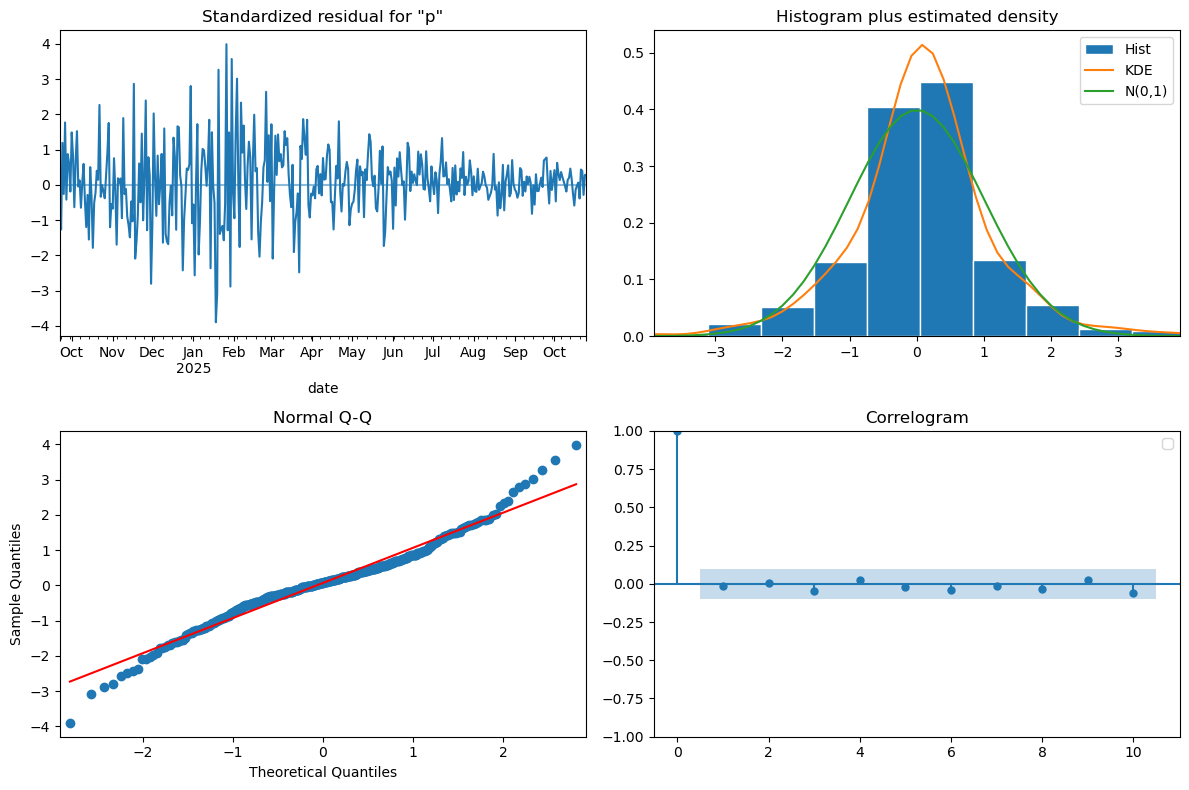

In [354]:
# Residual analysis for the best ARIMA model
best_arima_model.plot_diagnostics(figsize=(12, 8))
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [355]:
''' Fit and predict using the best ARIMA model on test set '''

predictions = best_arima_model.predict(start=test.index[0], end=test.index[-1])
inv_pred = inv_boxcox(predictions, lambda_)
train_actual_price = inv_boxcox(train['price_transformed'], lambda_)
test_actual_price = test['price']  # Use the original test prices for comparison

residuals = test_actual_price - inv_pred

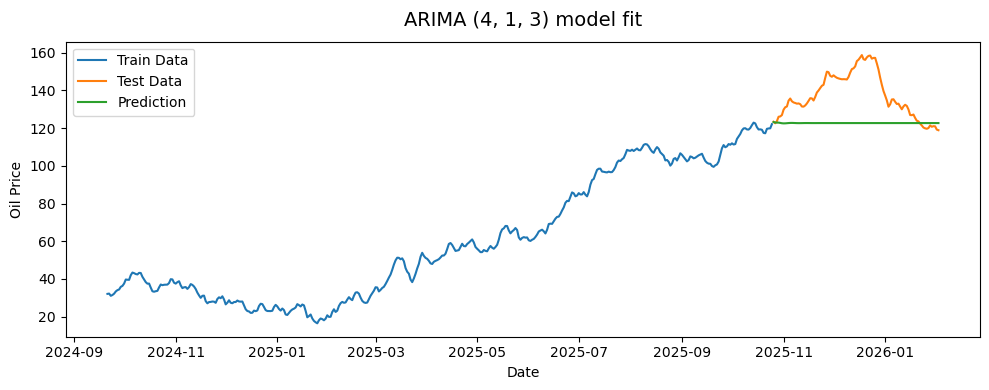

In [356]:
# Plot the graph for the Arimal Model
plt.figure(figsize=(10, 4))
plt.plot(train_actual_price, label='Train Data',)
plt.plot(test_actual_price, label='Test Data')
plt.plot(inv_pred, label='Prediction')
plt.title(f'ARIMA {best_model_order} model fit', fontsize=14, pad=12)
plt.xlabel('Date')
plt.ylabel('Oil Price')
plt.tight_layout()
plt.legend()
plt.show()

In [357]:
# Get the root mean squared error and mean absolute error of the residuals
print(f'Root Mean Squared Error (RMSE): {np.sqrt(np.mean(residuals**2)):.2f}')

Root Mean Squared Error (RMSE): 18.85


In [358]:
# Testing accuracy of the model using Mean Absolute Error (MAE), Mean Absolute Percentage Error (MAPE), and Root Mean Squared Error (RMSE)
arima_metrics_result = evaluate_model(test_actual_price, inv_pred, model_name=f'ARIMA')
print(arima_metrics_result)

ARIMA Performance:
MAE  : 15.32
RMSE : 18.85
MAPE : 10.56%
{'Model': 'ARIMA', 'MAE': np.float64(15.32), 'RMSE': np.float64(18.85), 'MAPE': np.float64(10.56)}


## Forecasting with Best Model
Using the .get_forecast() method

In [359]:
'''
    Make the predictions for 24 months ahead
    Using the .get_forecast method
'''

# Transform the data using Box-Cox transformation to stabilize variance
oil_df['price_transformed'], nlambda_ = boxcox(oil_df['price'])

# 24 months ahead (assuming 30 days in a month) 
steps = 730

# Fit model on final full series
final_model = ARIMA(oil_df['price_transformed'], order=best_model_order).fit()

predictions_int = final_model.get_forecast(steps=steps)

predicted_mean = pd.Series(predictions_int.predicted_mean)
conf_int = predictions_int.conf_int()

predicted_mean = inv_boxcox(predicted_mean, nlambda_)
conf_int = inv_boxcox(conf_int, nlambda_)

# Get the predicted daily values and confidence intervals
daily_forecast = predicted_mean.round(2)
daily_forecast_ci = conf_int.round(2)

In [360]:
# Generate confidence intervals data for the forecasted predictions
conf_df = pd.concat([daily_forecast, daily_forecast_ci], axis = 1)
conf_df.columns = ['Predicted Mean', 'Lower CI', 'Upper CI']

# Display the forecasted predictions and confidence intervals
conf_df.head(10)

,Predicted Mean,Lower CI,Upper CI
2026-02-03,118.99,115.33,122.74
2026-02-04,118.52,110.74,126.70
2026-02-05,118.16,108.10,128.89
2026-02-06,118.16,106.11,131.17
2026-02-07,118.33,104.16,133.85
2026-02-08,118.53,102.37,136.45
2026-02-09,118.66,100.84,138.66
2026-02-10,118.70,99.51,140.44
2026-02-11,118.66,98.32,141.90
2026-02-12,118.59,97.22,143.17


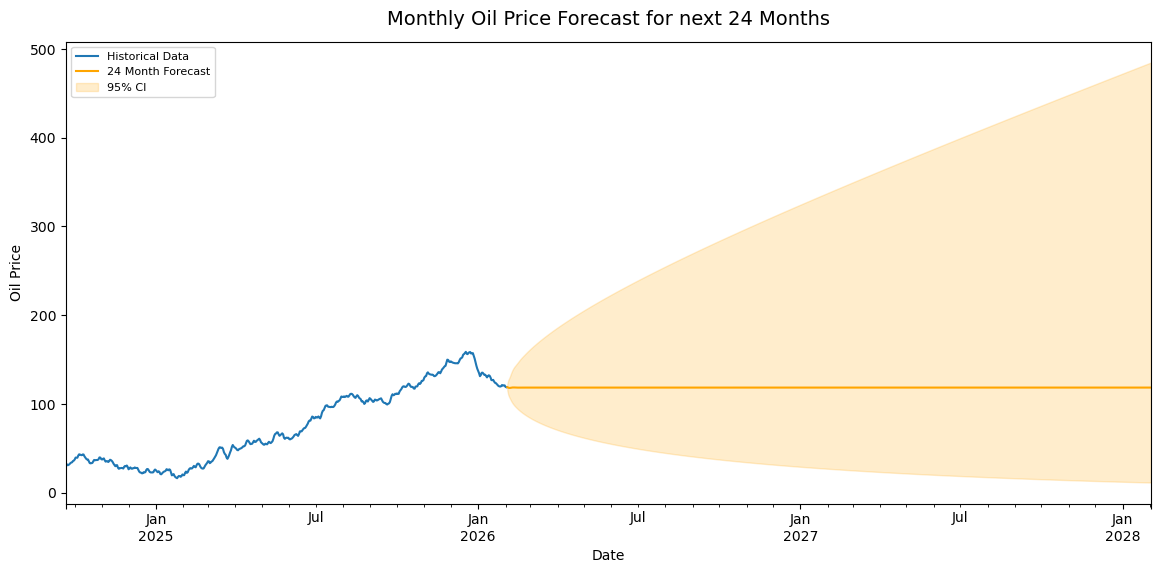

In [361]:
# plot historical data, forecasted predictions and confidence intervals
fig, ax = plt.subplots(figsize=(14,6))
oil_df['price'].plot(ax=ax, label='Historical Data')
daily_forecast.plot(ax=ax, label='24 Month Forecast', color='orange')
plt.fill_between(conf_df.index, conf_df['Lower CI'], conf_df['Upper CI'], color='orange', alpha=0.2, label='95% CI')

plt.xlabel('Date')
plt.ylabel('Oil Price')
plt.title('Monthly Oil Price Forecast for next 24 Months', fontsize=14, pad=12)
plt.legend(loc='best',fontsize=8)
plt.show()

In [362]:
print('='*50)
print('Building LSTM Model for time series analysis')
print('='*50)

Building LSTM Model for time series analysis


In [363]:
# Extract price column
data = oil_df['price'].values.reshape(-1, 1)

# Train-test split
train_size = int(len(data)*0.8)

# Specify indexes of training anf test data
train_data = data[:train_size]
test_data = data[train_size:]

# Print out len of training and test data
print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")

# Scale using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

scaled_data = np.vstack((train_scaled, test_scaled))

print(f"Scaled range: {scaled_data.min()} to {scaled_data.max()}")

Train size: 400
Test size: 100
Scaled range: 0.0 to 1.3366522637610372


In [364]:
# Create sequences for LSTM training
def create_sequences(data, lookback=60):
    """
    Returns sequences of data for LSTM training.
    X: Input sequences
    y: Target values
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


In [365]:
# Split data into train and test
def split_data(scaled_data, train_size, lookback):
    """
    Function splits the data into train and test sets based on the lookback window.
    """
    X, y = create_sequences(scaled_data, lookback)

    # Adjust split for rows lost to lookback window
    split = train_size - lookback

    X_train = X[:split].reshape(-1, lookback, 1)
    X_test  = X[split:].reshape(-1, lookback, 1)
    y_train = y[:split]
    y_test  = y[split:]

    print(f"  X_train : {X_train.shape}")
    print(f"  X_test  : {X_test.shape}")

    return X_train, X_test, y_train, y_test

In [366]:
# Define early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

In [367]:
def lookback_search(scaled_data, train_size, lookback_values, epochs=50):
    
    results = {}
    for lookback in lookback_values:
        X_train, X_test, y_train, y_test = split_data(scaled_data, train_size, lookback)

        model = Sequential([
            LSTM(64, input_shape=(lookback, 1), recurrent_dropout=0.2),
            Dropout(0.2),
            Dense(1)
        ])
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mae')
        model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=32,
            validation_data=(X_test, y_test),
            callbacks=[early_stop],
            verbose=0
        )

        val_loss = model.evaluate(X_test, y_test)
        results[lookback] = val_loss
        print(f"  Lookback {lookback:>3} → val_loss: {val_loss:.6f}")

    best_lookback = min(results, key=results.get)
    print(f'Best lookback found = {best_lookback} with val_loss = {results[best_lookback]:.6f}')
    return best_lookback

In [368]:
def grid_search(scaled_data, train_size, lookback, param_grid, epochs=50):
    """
    This function performs a grid search 
    over specified parameters 
    to find the best combination of values 
    for the LSTM Model
    """
    

    X_train, X_test, y_train, y_test = split_data(scaled_data, train_size, lookback)

    keys   = list(param_grid.keys())
    config = list(product(*param_grid.values()))

    best_loss   = np.inf
    best_params = None

    for fig in config:
        params = dict(zip(keys, fig))

        model = Sequential([
            LSTM(params['units'], return_sequences=True, input_shape=(lookback, 1), recurrent_dropout=params['dropout']),
            Dropout(params['dropout']),
            
            # Next layer uses the half of the first layer neurons
            LSTM(params['units'] // 2, recurrent_dropout=params['dropout']),
            Dropout(params['dropout']),
            Dense(1)
        ])
        
        model.compile(optimizer=Adam(learning_rate=params['learning_rate']), loss='mae')
        model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=params['batch_size'],
            validation_data=(X_test, y_test),
            callbacks=[early_stop],
            verbose=0
        )

        val_loss = model.evaluate(X_test, y_test, verbose=0)
        print(f"  {params} -- val_loss: {val_loss:.6f}")

        if val_loss < best_loss:
            best_loss   = val_loss
            best_params = params

    return best_params

In [369]:
# Find best lookback
best_lookback = lookback_search(scaled_data, train_size, lookback_values=[30, 45, 60])

  X_train : (370, 30, 1)
  X_test  : (100, 30, 1)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0253
  Lookback  30 → val_loss: 0.025325
  X_train : (355, 45, 1)
  X_test  : (100, 45, 1)
ERROR:tensorflow:==================================
Object was never used (type <class 'tensorflow.python.ops.tensor_array_ops.TensorArray'>):
If you want to mark it as used call its "mark_used()" method.
It was originally created here:
  File "C:\Users\aDEOLA Pc\AppData\Roaming\Python\Python313\site-packages\tensorflow\python\ops\while_loop.py", line 488, in while_loop
    loop_vars = body(*loop_vars)  File "C:\Users\aDEOLA Pc\AppData\Roaming\Python\Python313\site-packages\tensorflow\python\ops\while_loop.py", line 479, in <lambda>
    body = lambda i, lv: (i + 1, orig_body(*lv))  File "C:\Users\aDEOLA Pc\AppData\Roaming\Python\Python313\site-packages\keras\src\backend\tensorflow\rnn.py", line 426, in _step
    return (time + 1, output_ta_t) + tuple(new_states)  File "C:\Users\aDEOLA Pc\AppData\Roam

In [370]:
''' Use parameters to find optimal values and use for actual model training '''

# Perform hyperparameter search with best lookback found over the following parameters
param_grid = {
    'units':         [32, 50, 64],
    'dropout':       [0.1, 0.2],
    'learning_rate': [0.001, 0.0001],
    'batch_size':    [32, 64]
}

best_params_found = grid_search(scaled_data, train_size, best_lookback, param_grid)


# Extract parameters from best_params_found
units         = best_params_found['units']
dropout       = best_params_found['dropout']
learning_rate = best_params_found['learning_rate']
batch_size    = best_params_found['batch_size']

  X_train : (370, 30, 1)
  X_test  : (100, 30, 1)


  {'units': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 32} -- val_loss: 0.163457
  {'units': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 64} -- val_loss: 0.507055
  {'units': 32, 'dropout': 0.1, 'learning_rate': 0.0001, 'batch_size': 32} -- val_loss: 1.173573
  {'units': 32, 'dropout': 0.1, 'learning_rate': 0.0001, 'batch_size': 64} -- val_loss: 1.116681
  {'units': 32, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 32} -- val_loss: 0.087426
  {'units': 32, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 64} -- val_loss: 0.738285
  {'units': 32, 'dropout': 0.2, 'learning_rate': 0.0001, 'batch_size': 32} -- val_loss: 1.219115
  {'units': 32, 'dropout': 0.2, 'learning_rate': 0.0001, 'batch_size': 64} -- val_loss: 1.076846
  {'units': 50, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 32} -- val_loss: 0.071495
  {'units': 50, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 64} -- val_loss: 0.582546
  {'units': 50, 'dropout': 0.1, 'lea

In [371]:
# Split data with best lookback for final model training
X_train, X_test, y_train, y_test = split_data(scaled_data, train_size, best_lookback)

  X_train : (370, 30, 1)
  X_test  : (100, 30, 1)


In [372]:
# Build LSTM model
model = Sequential([
    # First LSTM layer
    LSTM(units, return_sequences=True, input_shape=(best_lookback, 1), recurrent_dropout=dropout), Dropout(dropout),
    
    # Second LSTM layer
    LSTM(units // 2, recurrent_dropout=dropout), Dropout(dropout),
    
    # Dense output layer
    Dense(1)
])


# Compile model
model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mae', metrics=[RootMeanSquaredError()])

# Display model summary
print('Built LSTM Architecture:')
model.summary()

Built LSTM Architecture:


Model: "sequential_69"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_125 (LSTM)                 │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_125 (Dropout)           │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_126 (LSTM)                 │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_126 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
print('Training LSTM model...')
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Training LSTM model...
Epoch 1/100


9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - loss: 0.1473 - root_mean_squared_error: 0.1911 - val_loss: 0.0526 - val_root_mean_squared_error: 0.0626
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0902 - root_mean_squared_error: 0.1108 - val_loss: 0.3429 - val_root_mean_squared_error: 0.3456
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0724 - root_mean_squared_error: 0.1003 - val_loss: 0.0385 - val_root_mean_squared_error: 0.0474
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0547 - root_mean_squared_error: 0.0709 - val_loss: 0.0754 - val_root_mean_squared_error: 0.0856
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0542 - root_mean_squared_error: 0.0711 - val_loss: 0.1251 - val_root_mean_squared_error: 0.1349
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0576 - root_mean_squared_error: 0.0779 - val_loss: 0.0438 - val_root_mean_squared_error: 0.0528
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0505 - root_mea

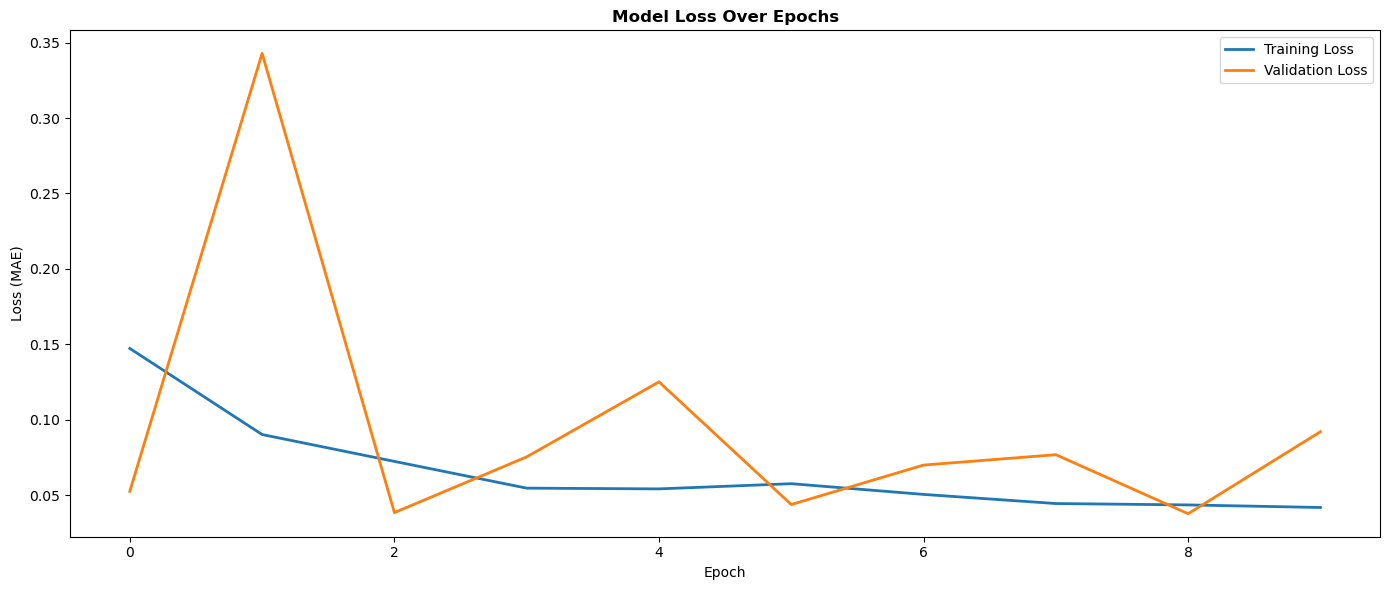

In [374]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot loss
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.legend()

plt.tight_layout()
plt.show()

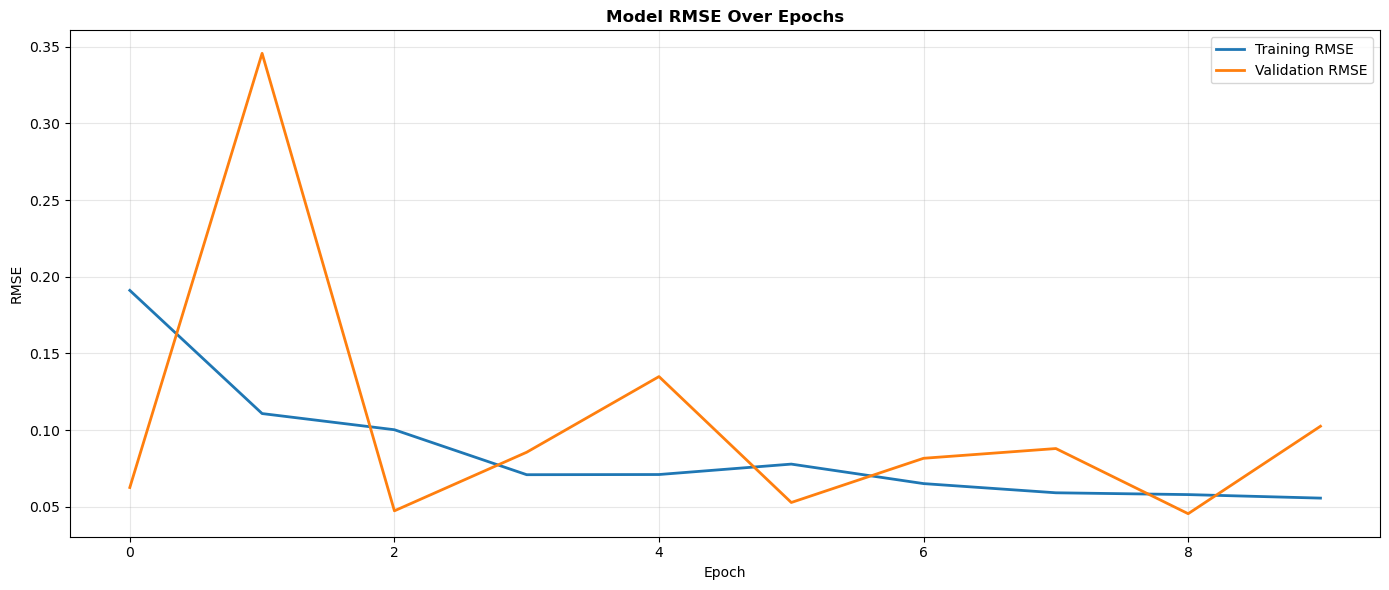

In [375]:
# Plot RMSE (Root Mean Squared Error)
fig, ax = plt.subplots(figsize=(14, 6))
plt.plot(history.history['root_mean_squared_error'], label='Training RMSE', linewidth=2)
plt.plot(history.history['val_root_mean_squared_error'], label='Validation RMSE', linewidth=2)
plt.title('Model RMSE Over Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [376]:
# Make predictions on training and test set
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


# Inverse transform predictions
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_train_actual_pred = scaler.inverse_transform(y_train_pred)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_actual_pred = scaler.inverse_transform(y_test_pred)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [377]:
# Calculate metrics for training set
evaluate_model(y_train_actual, y_train_actual_pred, model_name='LSTM - Train Set')

LSTM - Train Set Performance:
MAE  : 8.81
RMSE : 10.34
MAPE : 25.04%


{'Model': 'LSTM - Train Set',
 'MAE': np.float64(8.81),
 'RMSE': np.float64(10.34),
 'MAPE': np.float64(25.04)}

In [378]:
# Calculate metrics for test set
evaluate_model(y_test_actual, y_test_actual_pred, model_name='LSTM - Test Set')

LSTM - Test Set Performance:
MAE  : 13.58
RMSE : 16.16
MAPE : 9.48%


{'Model': 'LSTM - Test Set',
 'MAE': np.float64(13.58),
 'RMSE': np.float64(16.16),
 'MAPE': np.float64(9.48)}

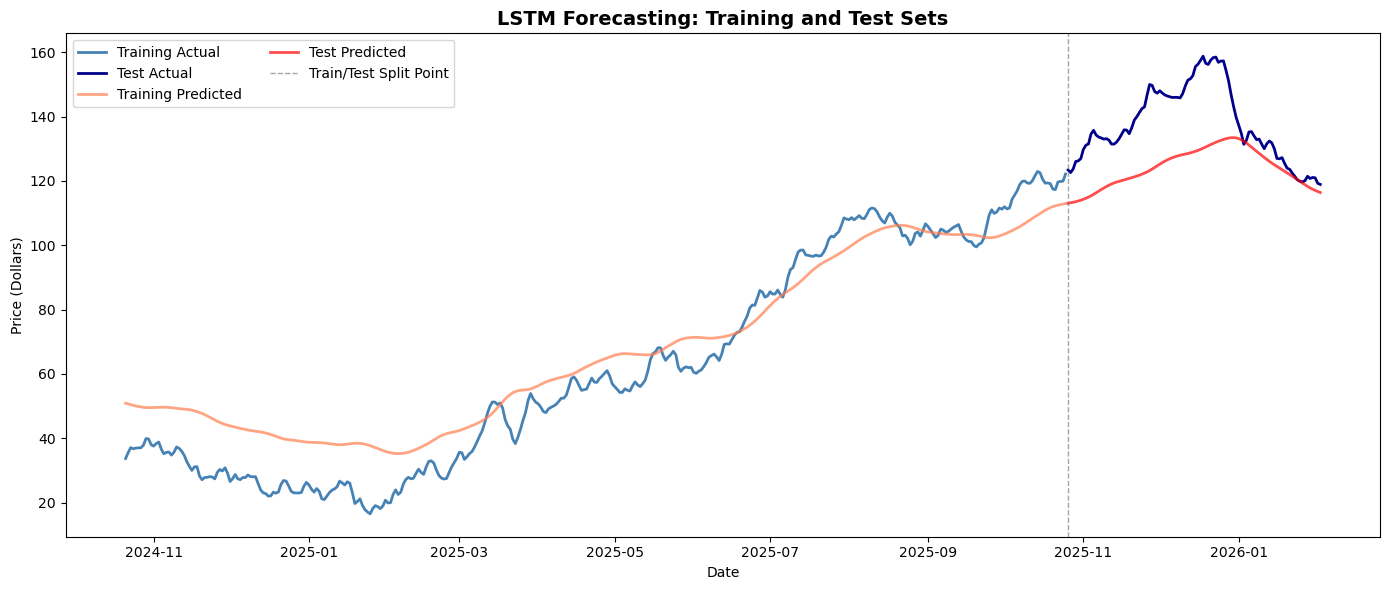

In [379]:
fig, ax = plt.subplots(figsize=(14, 6))

# Combine training and test dates
train_dates = oil_df.index[best_lookback:best_lookback+len(y_train)]
test_dates = oil_df.index[best_lookback+len(y_train):best_lookback+len(y_train)+len(y_test)]

# Plot actual prices
ax.plot(train_dates, y_train_actual, label='Training Actual', linewidth=2, color='steelblue')
ax.plot(test_dates, y_test_actual, label='Test Actual', linewidth=2, color='darkblue')

# Plot predicted prices
ax.plot(train_dates, y_train_actual_pred, label='Training Predicted', linewidth=2, color='coral', alpha=0.7)
ax.plot(test_dates, y_test_actual_pred, label='Test Predicted', linewidth=2, color='red', alpha=0.7)

# Vertical line to separate train/test split
ax.axvline(test_dates[0], color='grey', linestyle='--', linewidth=1, alpha=0.7, label='Train/Test Split Point')

ax.set_title('LSTM Forecasting: Training and Test Sets', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (Dollars)')
ax.legend(loc='best', fontsize=10, ncol=2)
plt.tight_layout()
plt.show()

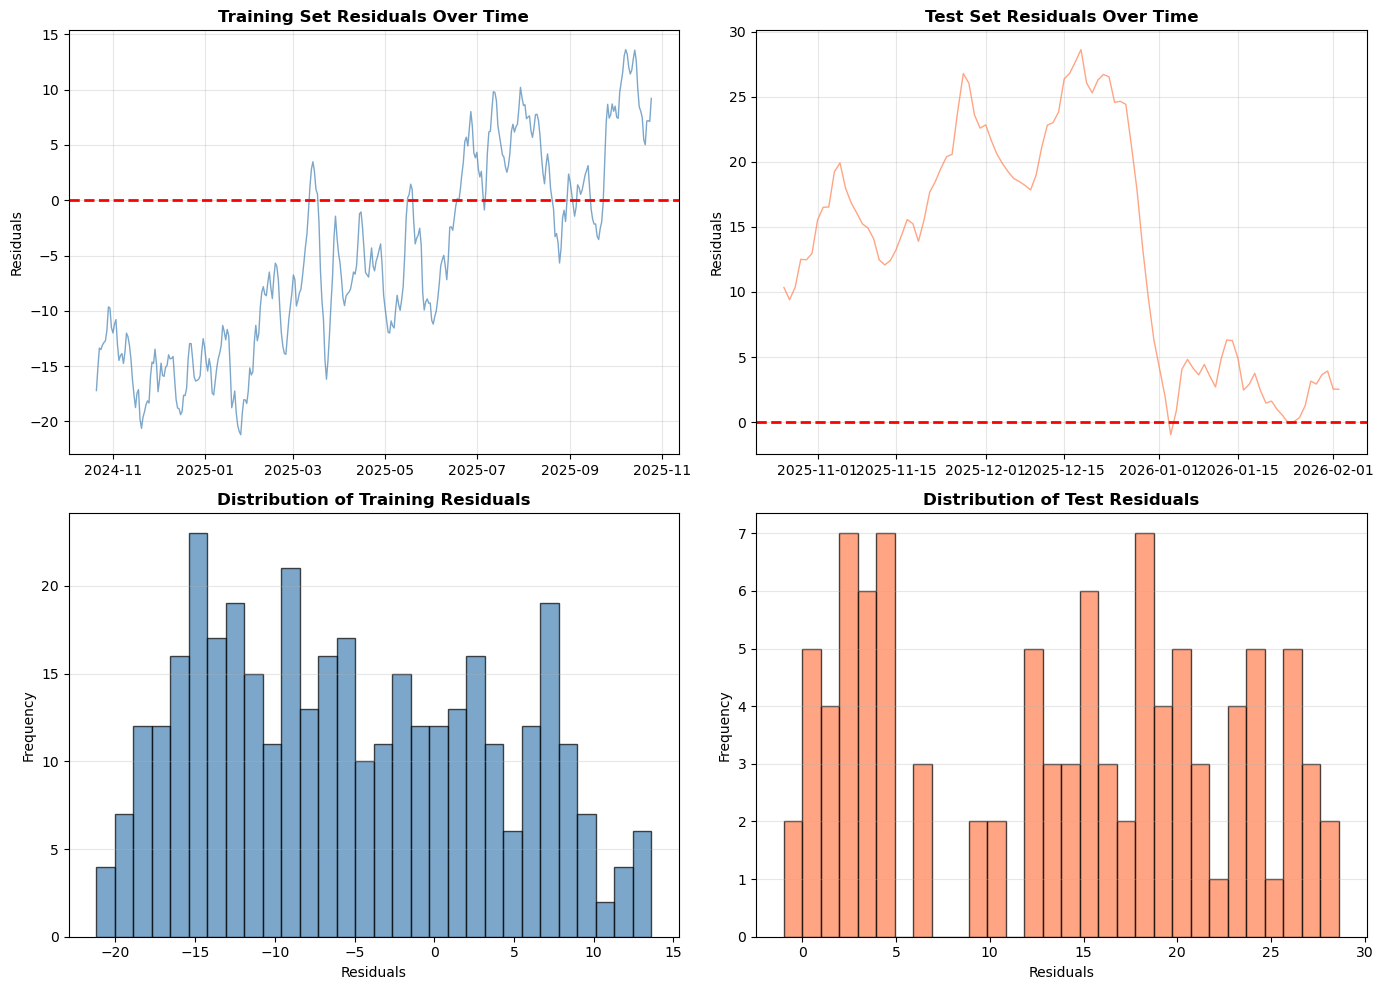

Residuals Analysis:
Training Mean Residual: -5.2730
Test Mean Residual: 13.5612


In [380]:
# Calculate residuals
train_residuals = y_train_actual - y_train_actual_pred
test_residuals = y_test_actual - y_test_actual_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training residuals over time
axes[0, 0].plot(train_dates, train_residuals, color='steelblue', alpha=0.7, linewidth=1)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title('Training Set Residuals Over Time', fontweight='bold')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].grid(True, alpha=0.3)

# Test residuals over time
axes[0, 1].plot(test_dates, test_residuals, color='coral', alpha=0.7, linewidth=1)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Test Set Residuals Over Time', fontweight='bold')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].grid(True, alpha=0.3)

# Training residuals distribution
axes[1, 0].hist(train_residuals, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribution of Training Residuals', fontweight='bold')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Test residuals distribution
axes[1, 1].hist(test_residuals, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribution of Test Residuals', fontweight='bold')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('Residuals Analysis:')
print(f'Training Mean Residual: {train_residuals.mean():.4f}')
print(f'Test Mean Residual: {test_residuals.mean():.4f}')

In [381]:
# Recall 24 months set for 730 days in arima prediction

forecast_days = 730
last_sequence = scaled_data[-best_lookback:]
lstm_predictions = []
current_sequence = scaled_data[-best_lookback:].reshape(1, best_lookback, 1)

for _ in range(forecast_days):
    pred = model(current_sequence, training=False).numpy()[0, 0]
    lstm_predictions.append(pred)
    current_sequence = np.append(current_sequence[:, 1:, :], [[[pred]]], axis=1)

lstm_predictions = np.array(lstm_predictions).reshape(-1,1)
future_prices = scaler.inverse_transform(lstm_predictions)

In [382]:
last_date = oil_df.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days,
    freq='D'
)

residuals = (y_test_actual - y_test_actual_pred).flatten()
residual_std = np.std(residuals)
ci_upper = future_prices.flatten() + 1.96*residual_std * np.sqrt(np.arange(1, forecast_days + 1))
ci_lower = future_prices.flatten() - 1.96*residual_std * np.sqrt(np.arange(1, forecast_days + 1))

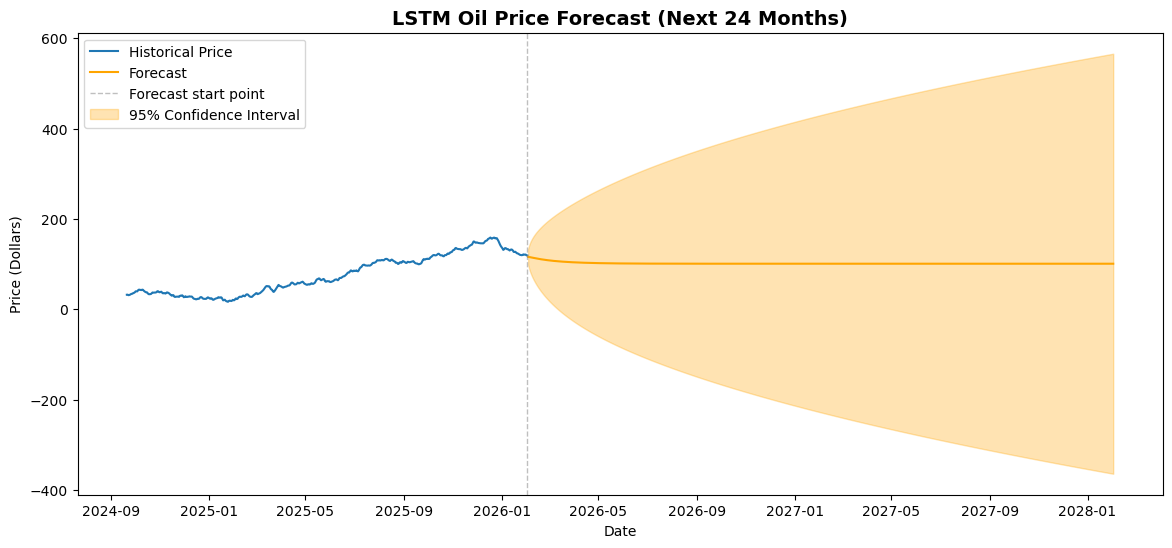

In [383]:
plt.figure(figsize=(14,6))
plt.plot(oil_df.index, oil_df['price'], label="Historical Price")
plt.plot(future_dates, future_prices, label="Forecast", color="orange")

# Add vertical line at forecast start
plt.axvline(oil_df.index[-1], color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Forecast start point')

# confidence interval
plt.fill_between(
    future_dates,
    ci_lower,
    ci_upper,
    color="orange",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("LSTM Oil Price Forecast (Next 24 Months)", fontweight='bold', fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (Dollars)")

plt.legend()
plt.show()